In [46]:
print ('Loading dependencies...', end = '')
try:
    import pandas as pd
    from tqdm import tqdm
    import numpy as np
    import os
    from Bio import SeqIO
    from Bio.SeqRecord import SeqRecord
    from Bio.Seq import Seq
    import sys
    from ete3 import NCBITaxa
    import matplotlib
    ncbi = NCBITaxa()
    print('Successful')
except:
    print('MISSING DEPENDENCIES!')

Loading dependencies...Successful


In [9]:
max_N=0.05
max_per_sp=2

In [28]:
# DEPRECATED: Sourcing from BOLD https://v3.boldsystems.org/index.php/Public_SearchTerms?query=Magnoliophyta[tax] 
# Download dataset from BOLD v4 with download_bold_v4.py 

In [29]:
df=pd.read_table('bold_data.txt',encoding = "latin").rename(columns={'species_name':'sci_name',
                'genus_name':'genus','family_name':'family'})
print(df.shape)
print(df.columns)
df[:2]

/tmp/ipykernel_50081/844653402.py:1: DtypeWarning: Columns (2,7,17,36,42,50,51,52,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_table('bold_data.txt',encoding = "latin").rename(columns={'species_name':'sci_name',


(487360, 80)
Index(['processid', 'sampleid', 'recordID', 'catalognum', 'fieldnum',
       'institution_storing', 'collection_code', 'bin_uri', 'phylum_taxID',
       'phylum_name', 'class_taxID', 'class_name', 'order_taxID', 'order_name',
       'family_taxID', 'family', 'subfamily_taxID', 'subfamily_name',
       'genus_taxID', 'genus', 'species_taxID', 'sci_name', 'subspecies_taxID',
       'subspecies_name', 'identification_provided_by',
       'identification_method', 'identification_reference', 'tax_note',
       'voucher_status', 'tissue_type', 'collection_event_id', 'collectors',
       'collectiondate_start', 'collectiondate_end', 'collectiontime',
       'collection_note', 'site_code', 'sampling_protocol', 'lifestage', 'sex',
       'reproduction', 'habitat', 'associated_specimens', 'associated_taxa',
       'extrainfo', 'notes', 'lat', 'lon', 'coord_source', 'coord_accuracy',
       'elev', 'depth', 'elev_accuracy', 'depth_accuracy', 'country',
       'province_state', 'regio

,processid,sampleid,recordID,catalognum,fieldnum,institution_storing,collection_code,bin_uri,phylum_taxID,phylum_name,...,genbank_accession,nucleotides,trace_ids,trace_names,trace_links,run_dates,sequencing_centers,directions,seq_primers,marker_codes
0,CPBOL1687-11,WangW-K9,1943394,NaN,WangW-K9,"Chinese Academy of Sciences, Institute of Botany",NaN,NaN,1321498.0,Tracheophyta,...,JN045078,CTAGCTGCTGTCGAGCTCCATCTATAAACGGATAAGACTAAGACTT...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CPBOL1687-11,WangW-K9,1943394,NaN,WangW-K9,"Chinese Academy of Sciences, Institute of Botany",NaN,NaN,1321498.0,Tracheophyta,...,JF954240,TCGGTTCTTTACGAACCCAGGGAAAATTTAGGTTATGACAATAAAC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df = df [['processid', 'sampleid', 'recordID', 'sci_name', 'genus', 'family','sequenceID', 
           'markercode', 'nucleotides']]
df[:2]

,processid,sampleid,recordID,sci_name,genus,family,sequenceID,markercode,nucleotides
0,CPBOL1687-11,WangW-K9,1943394,Kadsura longipedunculata,Kadsura,Schisandraceae,3923877.0,trnH-psbA,CTAGCTGCTGTCGAGCTCCATCTATAAACGGATAAGACTAAGACTT...
1,CPBOL1687-11,WangW-K9,1943394,Kadsura longipedunculata,Kadsura,Schisandraceae,3916862.0,matK,TCGGTTCTTTACGAACCCAGGGAAAATTTAGGTTATGACAATAAAC...


In [32]:
# Remove samples without species name
print(df.shape)
df = df[~df.sci_name.isna()]
df = df[~ (df.sci_name == ' ')]
print(df.shape)
# Remove samples without sequence
print(df.shape)
df = df[~df.nucleotides.isna()]
df = df[~ (df.nucleotides == ' ')]
print(df.shape)

(487360, 9)
(471150, 9)
(471150, 9)
(457388, 9)


In [33]:
df.groupby('markercode').size().sort_values(ascending=False)

markercode
matK                                                             117904
ITS2                                                              99725
ITS                                                               75056
rbcL                                                              72243
rbcLa                                                             64579
trnH-psbA                                                         15695
trnL-F                                                             3173
ITS1                                                               1842
rpoC1                                                              1465
atpF-atpH                                                          1274
rpoB                                                               1092
psbK-psbI                                                          1004
COI-5P                                                              724
trnL                                                 

In [34]:
df.loc[df.markercode=='rbcLa','markercode']='rbcL'

In [35]:
markers=['matK', 'ITS2', 'rbcL','trnH-psbA']

In [36]:
bold_df=df[df.markercode.isin(markers)]
bold_df['Seq']=bold_df.nucleotides.str.replace('-', '')
bold_df['Len']=bold_df.Seq.str.len()
bold_df = bold_df.rename(columns={'sequenceID':'Locus'})
print(bold_df.shape)
bold_df[:2]

(370146, 11)


/tmp/ipykernel_50081/3128474608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bold_df['Seq']=bold_df.nucleotides.str.replace('-', '')
/tmp/ipykernel_50081/3128474608.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bold_df['Len']=bold_df.Seq.str.len()


,processid,sampleid,recordID,sci_name,genus,family,Locus,markercode,nucleotides,Seq,Len
0,CPBOL1687-11,WangW-K9,1943394,Kadsura longipedunculata,Kadsura,Schisandraceae,3923877.0,trnH-psbA,CTAGCTGCTGTCGAGCTCCATCTATAAACGGATAAGACTAAGACTT...,CTAGCTGCTGTCGAGCTCCATCTATAAACGGATAAGACTAAGACTT...,319
1,CPBOL1687-11,WangW-K9,1943394,Kadsura longipedunculata,Kadsura,Schisandraceae,3916862.0,matK,TCGGTTCTTTACGAACCCAGGGAAAATTTAGGTTATGACAATAAAC...,TCGGTTCTTTACGAACCCAGGGAAAATTTAGGTTATGACAATAAAC...,1141


In [37]:
print(bold_df.isna().sum().to_dict())
print(bold_df.nunique().to_dict())

{'processid': 0, 'sampleid': 0, 'recordID': 0, 'sci_name': 0, 'genus': 337, 'family': 0, 'Locus': 0, 'markercode': 0, 'nucleotides': 0, 'Seq': 0, 'Len': 0}
{'processid': 270955, 'sampleid': 270954, 'recordID': 270956, 'sci_name': 85887, 'genus': 11458, 'family': 425, 'Locus': 370146, 'markercode': 4, 'nucleotides': 254209, 'Seq': 247742, 'Len': 1682}


## Filter using WCVP

In [38]:
rm_char='[]()'
for char in rm_char:
    bold_df['sci_name'] = bold_df['sci_name'].str.replace(char,'')

In [39]:
print('sending',bold_df.sci_name.nunique(),'species names to WCVP_taxo')
bold_df.groupby('sci_name').head(1).sci_name.to_csv('BOLD_species.csv',index=False)

sending 85887 species names to WCVP_taxo


In [40]:
bold_df.columns

Index(['processid', 'sampleid', 'recordID', 'sci_name', 'genus', 'family',
       'Locus', 'markercode', 'nucleotides', 'Seq', 'Len'],
      dtype='object')

In [41]:
print('running wcvp_taxo',end='...')
print(os.system('python ../WCVP_Taxo/wcvp_taxo.py ../WCVP_Taxo/wcvp_names.csv ' + \
          'BOLD_species.csv' + ' -g -s similarity_genus -d divert_genusOK'))
wcvp = pd.read_csv('BOLD_species' + '_wcvp.csv')
wcvp = wcvp[wcvp.sci_name.notnull()]
print('found',wcvp.sci_name.nunique(),'species in WCVP')
print(bold_df.shape[0],end=' > ')
bold_df = pd.merge(bold_df.rename(columns={'sci_name':'Ini_sci_name'}).drop(columns=['family','genus']),
                   wcvp,how='inner',on='Ini_sci_name')
print(bold_df.shape[0])
print('f:',bold_df.family.nunique(),'g:',bold_df.genus.nunique(),'s:',bold_df.sci_name.nunique())

running wcvp_taxo...

/home/berta/dev/PAFTOL_Validation_Pipeline/Barcode_Databases/../WCVP_Taxo/wcvp_taxo.py:175: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  wcvp = pd.read_table(wcvp_path,sep='|',encoding='utf-8')




##### wcvp_taxo v0.6 ##### 
Author:   Kevin Leempoel 
Last update (reviewed B. Gallego): 2024-04-14

../WCVP_Taxo/wcvp_names.csv BOLD_species.csv g: True  s: similarity_genus  d: divert_genusOK  oc: False  os: False  v: False


Loading and preparing data
Loading WCVP...
parent taxa information added to WCVP backbone.

accepted taxa information added to WCVP backbone.
found .csv, saving to .pkl...1440076 entries
Loading dataset...85887 entries

Scientific Name is sci_name
No ID column, create ID from index


Initial checks
Genus sp: 3308 IDs with Genus sp. as sci_name
Missing taxa: 5780 IDs not in WCVP

Looking for most similar names


  0%|          | 0/5780 [00:00<?, ?it/s]/home/berta/dev/PAFTOL_Validation_Pipeline/Barcode_Databases/../WCVP_Taxo/wcvp_taxo.py:426: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Tetrastigma erubescens' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx,'Similar_sci_name']=find_sim(row.sci_name, wcvp, only_from_genus=True)
100%|██████████| 5780/5780 [02:09<00:00, 44.78it/s]


find_most_similar: found 2841 IDs by similarity
Duplicates: 4981 IDs matching multiple entries in WCVP
No match for 2939 IDs


Matching & Resolving
After direct matching: found match for 64454 IDs
After resolving synonyms: found match for 77583 IDs
Duplicates: found 5835 entries, for 4942 duplicated ID, corresponding to 5500 kew_id
Unresolved duplicates: writing separate spreadsheet with 398 entries, for 189 duplicated ID, corresponding to 303 kew_id
After resolving duplicates: found match for 82336 IDs
After filtering of duplicates divert_genusOK : kept 85887
After divert_genusOK : kept 85659 IDs
2939 Samples are unresolved, no similar match in WCVP
After discarding unresolved: kept 82720 IDs
Done!
0


/tmp/ipykernel_50081/633013821.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  wcvp = pd.read_csv('BOLD_species' + '_wcvp.csv')


found 75305 species in WCVP
370146 > 358153
f: 414 g: 10530 s: 75305


In [42]:
rm_char='[]()×'
for char in rm_char:
    bold_df['sci_name'] = bold_df['sci_name'].str.replace(char,'')

## Save to fasta

In [43]:
def writefasta(rec_df, marker):
    rec_fasta=[]
    for idx, row in rec_df.iterrows():
        record = SeqRecord(Seq(row.Seq))
        record.id = str(row.Locus)
        record.description = ';' \
        + 'f=' + row.family + ',g=' + row.genus + ',s=' + row.sci_name + ',ini_s=' + row.Ini_sci_name + ';'
        rec_fasta.append(record)
#     return rec_fasta
    SeqIO.write(rec_fasta,'BOLD_' + marker + '.fasta',format='fasta')

f: 408 g: 8315 s: 42444
{0.01: 444.0, 0.05: 512.0, 0.1: 532.0, 0.5: 552.0, 0.9: 1356.0, 0.95: 1389.0, 0.99: 1434.0}
132429 > 73829 > 37060
{0.01: 522.0, 0.05: 528.0, 0.1: 540.0, 0.5: 552.0, 0.9: 565.0, 0.95: 571.0, 0.99: 577.0}
f: 333 g: 5135 s: 24443


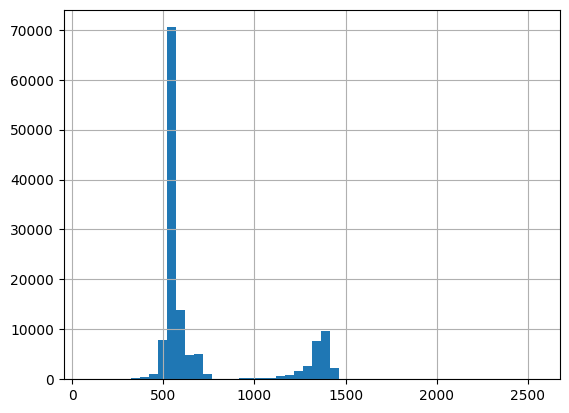

In [47]:
marker = 'rbcLa'
bold_marker=bold_df[bold_df.markercode=='rbcL']
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
bold_marker.Len.hist(bins=50);
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker[(bold_marker.Len>=520) & (bold_marker.Len<=580)]
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker.sort_values('family').groupby('sci_name').head(2)
print(bold_marker.shape[0])
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
writefasta(bold_marker,marker)
bold_marker[['Locus','Len',
          'sci_name', 'kew_id','family', 'genus', 'species', 'infraspecies', 'Duplicates',
          'Ini_sci_name']].to_csv('BOLD_' + marker + '_TAXO.csv',index=False)
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())

f: 408 g: 8315 s: 42444
{0.01: 444.0, 0.05: 512.0, 0.1: 532.0, 0.5: 552.0, 0.9: 1356.0, 0.95: 1389.0, 0.99: 1434.0}
132429 > 24308 > 21375
{0.01: 1212.0, 0.05: 1251.0, 0.1: 1281.0, 0.5: 1362.0, 0.9: 1392.0, 0.95: 1431.0, 0.99: 1458.0}
f: 401 g: 6158 s: 17543


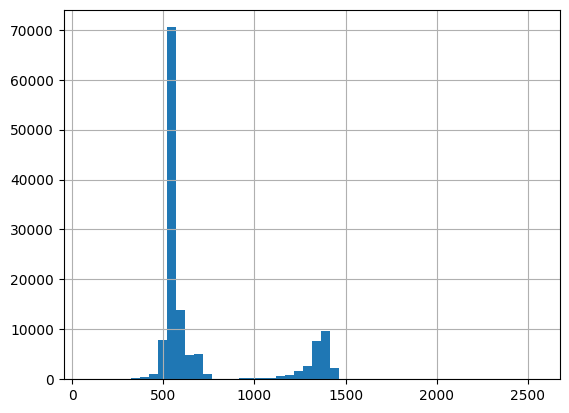

In [48]:
marker = 'rbcL'
bold_marker=bold_df[bold_df.markercode==marker]
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
bold_marker.Len.hist(bins=50);
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker[(bold_marker.Len>=1200) & (bold_marker.Len<=1500)]
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker.sort_values('family').groupby('sci_name').head(2)
print(bold_marker.shape[0])
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
writefasta(bold_marker,marker)
bold_marker[['Locus','Len',
          'sci_name', 'kew_id','family', 'genus', 'species', 'infraspecies', 'Duplicates',
          'Ini_sci_name']].to_csv('BOLD_' + marker + '_TAXO.csv',index=False)
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())

f: 399 g: 8349 s: 46320
{0.01: 343.0, 0.05: 543.0, 0.1: 651.0, 0.5: 806.0, 0.9: 1527.0, 0.95: 1539.0, 0.99: 1566.0}
114305 > 76326 > 42143
{0.01: 523.0, 0.05: 605.0, 0.1: 664.0, 0.5: 780.0, 0.9: 858.0, 0.95: 892.0, 0.99: 978.0}
f: 354 g: 5631 s: 29070


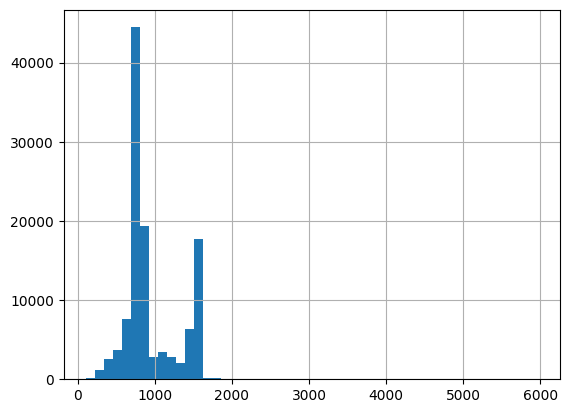

In [49]:
marker = 'matK'
bold_marker=bold_df[bold_df.markercode==marker]
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
bold_marker.Len.hist(bins=50);
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker[(bold_marker.Len>=500) & (bold_marker.Len<=1000)]
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker.sort_values('family').groupby('sci_name').head(2)
print(bold_marker.shape[0])
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
writefasta(bold_marker,marker)
bold_marker[['Locus','Len',
          'sci_name', 'kew_id','family', 'genus', 'species', 'infraspecies', 'Duplicates',
          'Ini_sci_name']].to_csv('BOLD_' + marker + '_TAXO.csv',index=False)
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())

f: 297 g: 6322 s: 40215
{0.01: 168.0, 0.05: 193.0, 0.1: 204.0, 0.5: 231.0, 0.9: 370.0, 0.95: 446.0, 0.99: 470.0}
96794 > 65658 > 42994
{0.01: 176.0, 0.05: 191.0, 0.1: 201.0, 0.5: 221.0, 0.9: 250.0, 0.95: 261.0, 0.99: 276.0}
f: 238 g: 5236 s: 32761


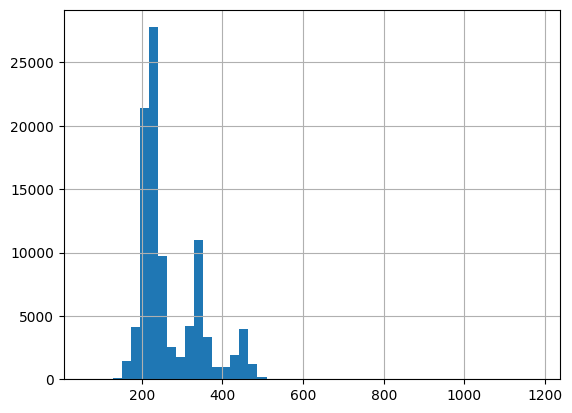

In [50]:
marker = 'ITS2'
bold_marker=bold_df[bold_df.markercode==marker]
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
bold_marker.Len.hist(bins=50);
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker[(bold_marker.Len>=170) & (bold_marker.Len<=280)]
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker.sort_values('family').groupby('sci_name').head(2)
print(bold_marker.shape[0])
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
writefasta(bold_marker,marker)
bold_marker[['Locus','Len',
          'sci_name', 'kew_id','family', 'genus', 'species', 'infraspecies', 'Duplicates',
          'Ini_sci_name']].to_csv('BOLD_' + marker + '_TAXO.csv',index=False)
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())

f: 250 g: 2070 s: 5589
{0.01: 199.0, 0.05: 244.0, 0.1: 277.0, 0.5: 428.0, 0.9: 607.0, 0.95: 631.0, 0.99: 731.7600000000002}
14625 > 14028 > 8062
{0.01: 217.0, 0.05: 251.05, 0.1: 279.0, 0.5: 425.0, 0.9: 585.0, 0.95: 618.0, 0.99: 641.0}
f: 242 g: 1990 s: 5316


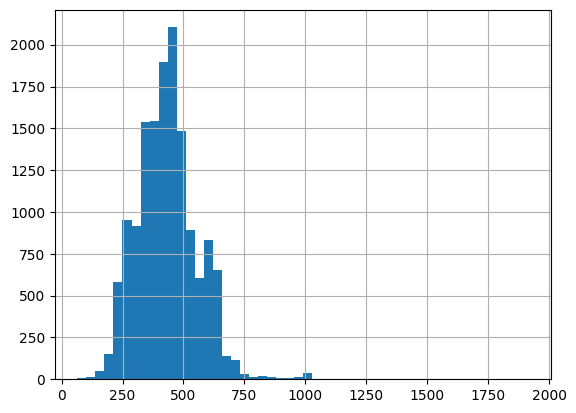

In [51]:
marker = 'trnH-psbA'
bold_marker=bold_df[bold_df.markercode==marker]
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
bold_marker.Len.hist(bins=50);
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker[(bold_marker.Len>=200) & (bold_marker.Len<=650)]
print(bold_marker.shape[0],end=' > ')
bold_marker = bold_marker.sort_values('family').groupby('sci_name').head(2)
print(bold_marker.shape[0])
print(bold_marker.Len.quantile([0.01, 0.05, .1, .5, 0.9, 0.95, 0.99]).to_dict())
writefasta(bold_marker,marker)
bold_marker[['Locus','Len',
          'sci_name', 'kew_id','family', 'genus', 'species', 'infraspecies', 'Duplicates',
          'Ini_sci_name']].to_csv('BOLD_' + marker + '_TAXO.csv',index=False)
print('f:',bold_marker.family.nunique(),'g:',bold_marker.genus.nunique(),'s:',bold_marker.sci_name.nunique())